In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
# Normalization를 위한 mean, std 값 구하기

_dataset = datasets.ImageFolder(root='./datasets/cifar10/train', transform=transforms.ToTensor())
_loader  = DataLoader(_dataset)  # batch_size를 지정하지 않으면 모든 데이터를 한 번에 처리

images, _ = next(iter(_loader))

# (batch, channel, height, width) axes 중에서 channel 만 남기고, 나머지 axis들을 모두 평균값 계산
mean = images.mean(dim=[0, 2, 3])
std  = images.std(dim=[0, 2, 3])
mean, std

(tensor([0.5800, 0.5830, 0.5853]), tensor([0.3607, 0.3628, 0.3518]))

In [31]:
MEAN = (0.5800, 0.5830, 0.5853)
STD  = (0.3607, 0.3628, 0.3518)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

In [32]:
train_dataset = datasets.ImageFolder(root='./datasets/cifar10/train', transform=train_transform)
test_dataset  = datasets.ImageFolder(root='./datasets/cifar10/test',  transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

In [33]:
class DNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),  # (batch, 3, 32, 32) → (batch, 3072(3*32*32))

            nn.Linear(3072, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.net(x)

model = DNN().to(device)

In [34]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0007)

In [35]:
train_losses, test_losses         = [], []
train_accuracies, test_accuracies = [], []

In [36]:
epochs = 20

for epoch in range(epochs):

    # ── Train ──
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc  = 100 * correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ── Test ──
    model.eval()
    correct_test, total_test, test_loss = 0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total_test   += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_loss = test_loss / len(test_loader)
    test_acc  = 100 * correct_test / total_test

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} | "
          f"Test Loss: {test_loss:.4f} | "
          f"Train Acc: {train_acc:.2f}% | "
          f"Test Acc: {test_acc:.2f}%")

Epoch [1/20] Train Loss: 1.9121 | Test Loss: 1.6496 | Train Acc: 30.05% | Test Acc: 40.28%
Epoch [2/20] Train Loss: 1.7483 | Test Loss: 1.5469 | Train Acc: 36.86% | Test Acc: 44.06%
Epoch [3/20] Train Loss: 1.6919 | Test Loss: 1.4922 | Train Acc: 39.05% | Test Acc: 45.71%
Epoch [4/20] Train Loss: 1.6473 | Test Loss: 1.4756 | Train Acc: 40.73% | Test Acc: 46.61%
Epoch [5/20] Train Loss: 1.6178 | Test Loss: 1.4380 | Train Acc: 41.54% | Test Acc: 48.97%
Epoch [6/20] Train Loss: 1.5977 | Test Loss: 1.4169 | Train Acc: 42.57% | Test Acc: 48.74%
Epoch [7/20] Train Loss: 1.5767 | Test Loss: 1.3709 | Train Acc: 43.11% | Test Acc: 50.14%
Epoch [8/20] Train Loss: 1.5604 | Test Loss: 1.3812 | Train Acc: 44.09% | Test Acc: 50.25%
Epoch [9/20] Train Loss: 1.5439 | Test Loss: 1.3597 | Train Acc: 44.58% | Test Acc: 50.76%
Epoch [10/20] Train Loss: 1.5364 | Test Loss: 1.3399 | Train Acc: 44.81% | Test Acc: 51.37%
Epoch [11/20] Train Loss: 1.5189 | Test Loss: 1.3448 | Train Acc: 45.31% | Test Acc: 51.9

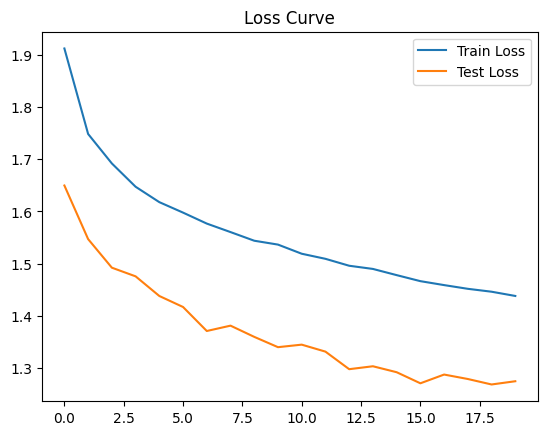

In [37]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses,  label="Test Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

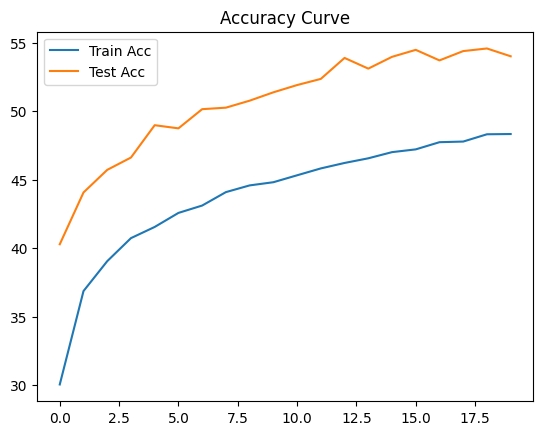

In [38]:
plt.figure()
plt.plot(train_accuracies, label="Train Acc")
plt.plot(test_accuracies,  label="Test Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

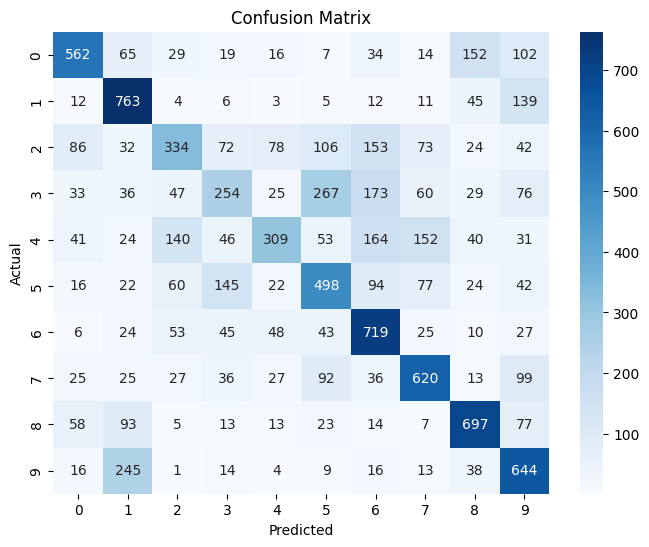

In [39]:
all_preds  = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


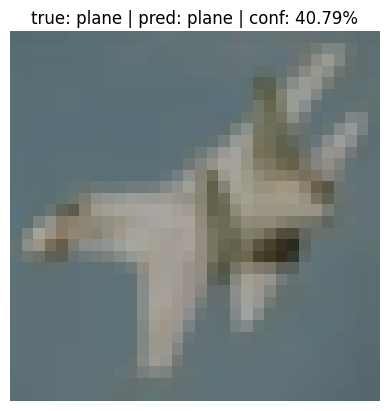

In [40]:
CLASSES = ("plane","car","bird","cat","deer","dog","frog","horse","ship","truck")
MEAN = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
STD  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

images, labels = next(iter(test_loader))

idx          = 1
single_image = images[idx].unsqueeze(0)
true_label   = labels[idx].item()

with torch.no_grad():
    output     = model(single_image.to(device))
    probs      = torch.softmax(output, dim=1)
    pred_label = torch.argmax(probs, dim=1).item()
    confidence = probs[0][pred_label].item()

img = images[idx] * STD + MEAN
img = img.permute(1, 2, 0).clamp(0, 1)

plt.imshow(img)
plt.title(f"true: {CLASSES[true_label]} | pred: {CLASSES[pred_label]} | conf: {confidence:.2%}")
plt.axis('off')
plt.show()